# Credit Card Fraud Detection — Exploratory Data Analysis

This notebook explores the **Kaggle Credit Card Fraud Detection** dataset, which contains 284,807 transactions made by European cardholders in September 2013. Of these, only 492 are fraudulent — representing just **0.172%** of all transactions.

Because the dataset is so highly imbalanced, standard accuracy is misleading. Our goal is to understand the data distributions, identify features that discriminate fraud from legitimate transactions, and prepare for modeling with appropriate sampling techniques.

In [1]:
import os
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
sns.set_palette('husl')
%matplotlib inline

print('Libraries loaded successfully')

Libraries loaded successfully


## Load Data

In [2]:
import os, sys
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('.')), ''))
# Load data - user should place creditcard.csv in data/
DATA_PATH = '../data/creditcard.csv'
if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
else:
    # Generate synthetic data for demonstration
    np.random.seed(42)
    n = 10000
    fraud_n = 17
    normal = pd.DataFrame(np.random.randn(n - fraud_n, 30), columns=[f'V{i}' for i in range(1,29)] + ['Time','Amount'])
    fraud = pd.DataFrame(np.random.randn(fraud_n, 30) * 2 + 3, columns=[f'V{i}' for i in range(1,29)] + ['Time','Amount'])
    normal['Class'] = 0
    fraud['Class'] = 1
    df = pd.concat([normal, fraud], ignore_index=True)
    print("Using synthetic demo data (place creditcard.csv in data/ for real analysis)")
print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Dataset Overview

In [3]:
print('=== DataFrame Info ===')
df.info()
print('\n=== Descriptive Statistics ===')
df.describe()

=== DataFrame Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## Class Distribution

Total transactions : 284,807
Legitimate (0)     : 284,315 (99.827%)
Fraudulent (1)     : 492 (0.173%)

Fraud rate: 0.1727%


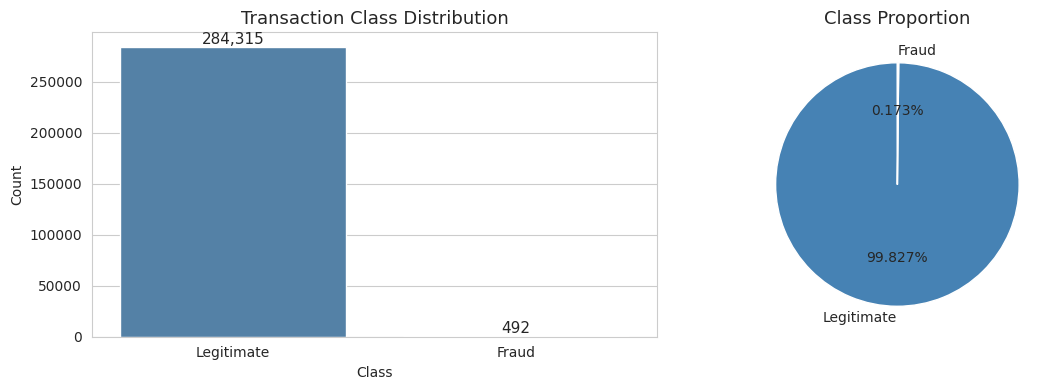

In [4]:
class_counts = df['Class'].value_counts()
fraud_rate = df['Class'].mean() * 100

print(f'Total transactions : {len(df):,}')
print(f'Legitimate (0)     : {class_counts[0]:,} ({100 - fraud_rate:.3f}%)')
print(f'Fraudulent (1)     : {class_counts[1]:,} ({fraud_rate:.3f}%)')
print(f'\nFraud rate: {fraud_rate:.4f}%')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
sns.countplot(x='Class', data=df, ax=axes[0], palette=['steelblue', 'tomato'])
axes[0].set_title('Transaction Class Distribution', fontsize=13)
axes[0].set_xticklabels(['Legitimate', 'Fraud'])
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11)

# Pie chart
axes[1].pie(
    class_counts.values,
    labels=['Legitimate', 'Fraud'],
    autopct='%1.3f%%',
    colors=['steelblue', 'tomato'],
    startangle=90,
)
axes[1].set_title('Class Proportion', fontsize=13)

plt.tight_layout()
plt.show()

## Feature Distributions

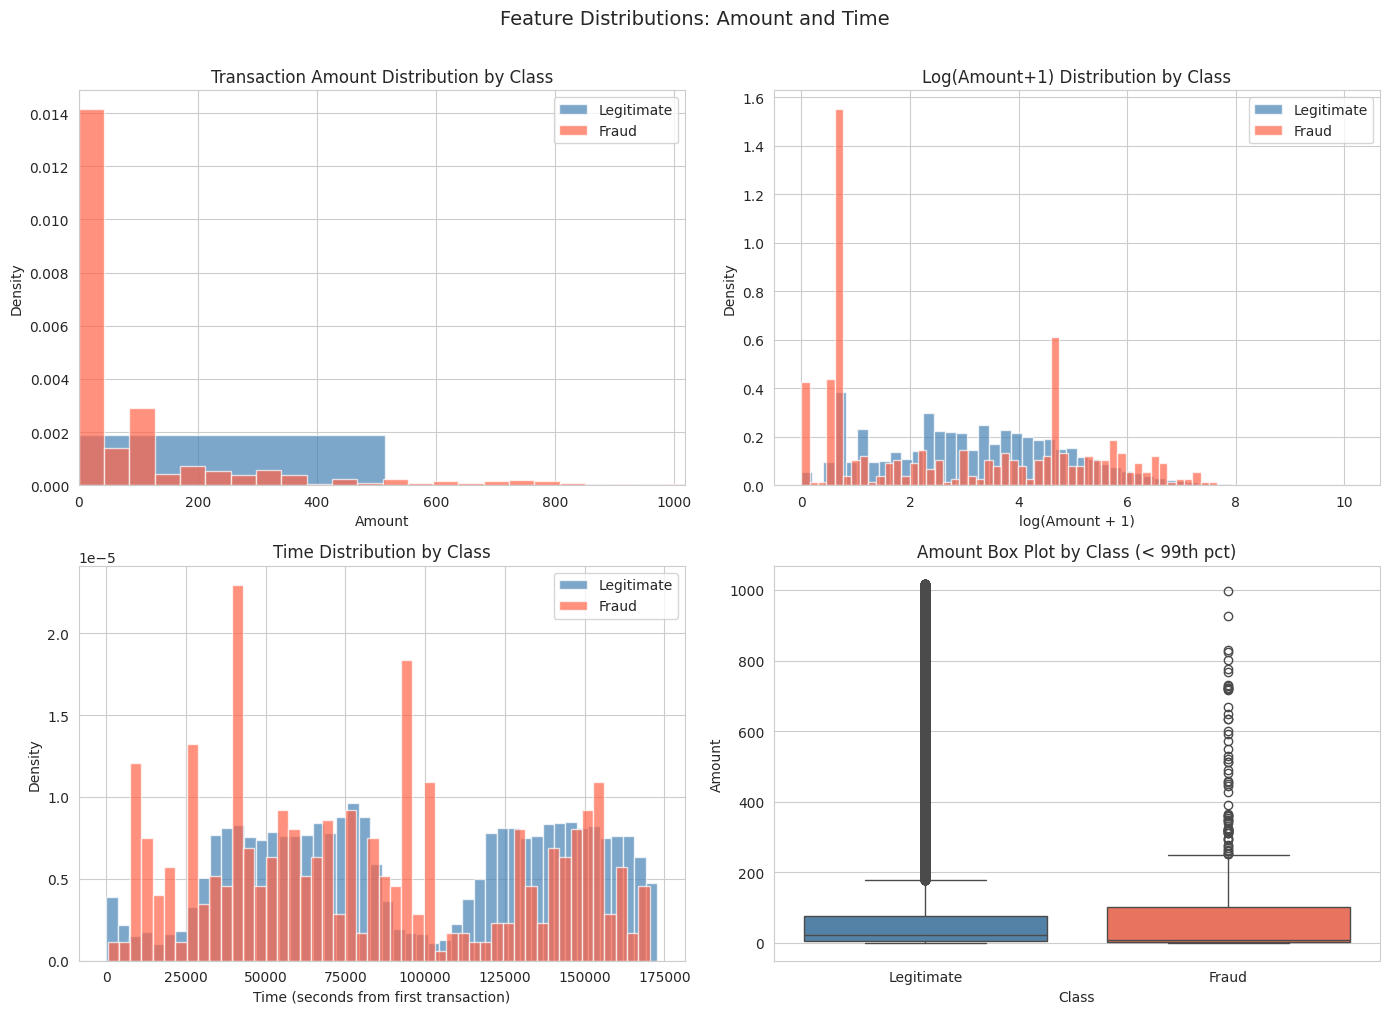

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Amount distribution by class
for cls, color, label in [(0, 'steelblue', 'Legitimate'), (1, 'tomato', 'Fraud')]:
    axes[0, 0].hist(
        df[df['Class'] == cls]['Amount'],
        bins=50, alpha=0.7, color=color, label=label, density=True
    )
axes[0, 0].set_title('Transaction Amount Distribution by Class', fontsize=12)
axes[0, 0].set_xlabel('Amount')
axes[0, 0].set_ylabel('Density')
axes[0, 0].legend()
axes[0, 0].set_xlim(0, df['Amount'].quantile(0.99))

# Log-scaled Amount
log_amount = df['Amount'].apply(lambda x: np.log1p(x))
for cls, color, label in [(0, 'steelblue', 'Legitimate'), (1, 'tomato', 'Fraud')]:
    axes[0, 1].hist(
        log_amount[df['Class'] == cls],
        bins=50, alpha=0.7, color=color, label=label, density=True
    )
axes[0, 1].set_title('Log(Amount+1) Distribution by Class', fontsize=12)
axes[0, 1].set_xlabel('log(Amount + 1)')
axes[0, 1].set_ylabel('Density')
axes[0, 1].legend()

# Time distribution by class
for cls, color, label in [(0, 'steelblue', 'Legitimate'), (1, 'tomato', 'Fraud')]:
    axes[1, 0].hist(
        df[df['Class'] == cls]['Time'],
        bins=48, alpha=0.7, color=color, label=label, density=True
    )
axes[1, 0].set_title('Time Distribution by Class', fontsize=12)
axes[1, 0].set_xlabel('Time (seconds from first transaction)')
axes[1, 0].set_ylabel('Density')
axes[1, 0].legend()

# Box plot of Amount by class
df_plot = df[df['Amount'] < df['Amount'].quantile(0.99)].copy()
df_plot['Class_label'] = df_plot['Class'].map({0: 'Legitimate', 1: 'Fraud'})
sns.boxplot(x='Class_label', y='Amount', data=df_plot, ax=axes[1, 1],
            palette=['steelblue', 'tomato'])
axes[1, 1].set_title('Amount Box Plot by Class (< 99th pct)', fontsize=12)
axes[1, 1].set_xlabel('Class')
axes[1, 1].set_ylabel('Amount')

plt.suptitle('Feature Distributions: Amount and Time', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Correlation Analysis

Top 15 features most correlated with Class (|r|):
V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
V7     0.187257
V11    0.154876
V4     0.133447
V18    0.111485
V1     0.101347
V9     0.097733
V5     0.094974
V2     0.091289
V6     0.043643


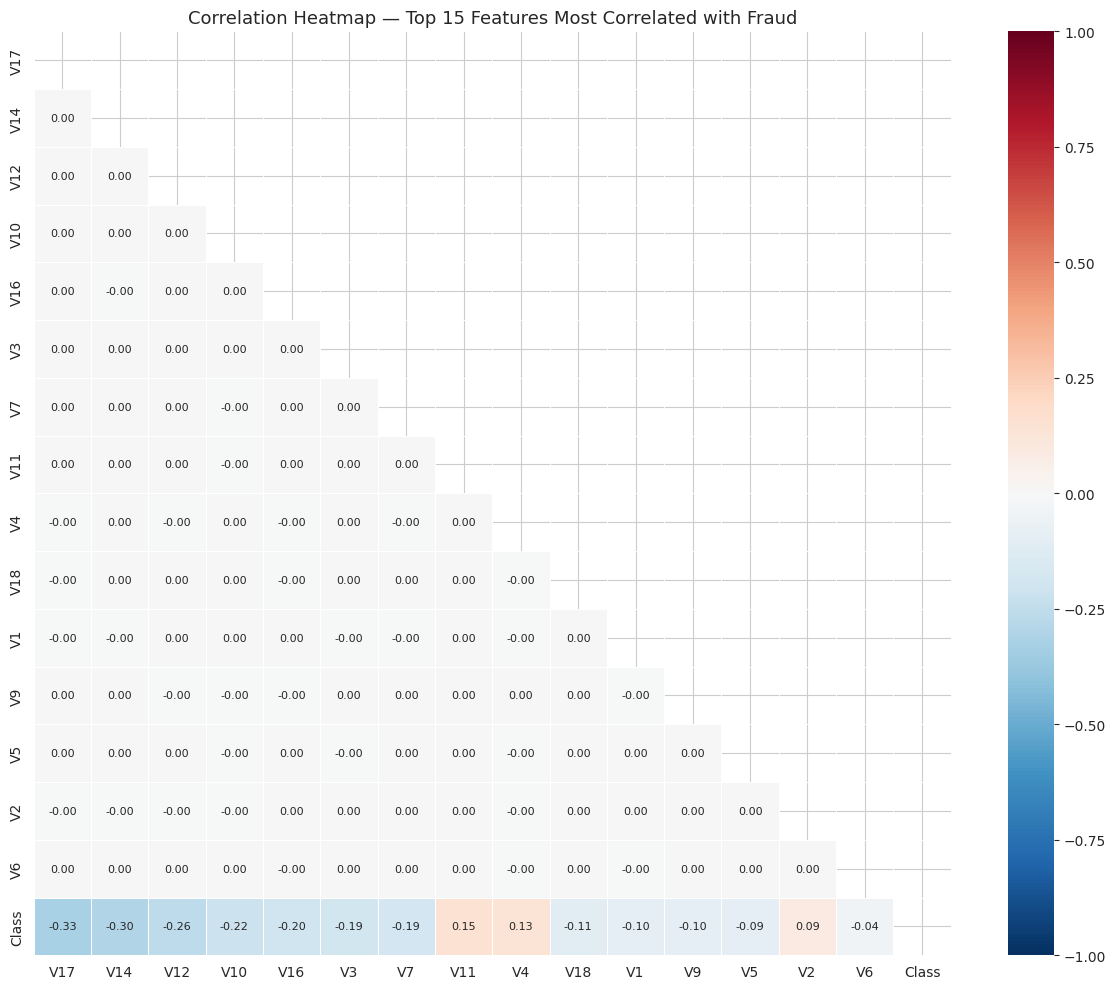

In [6]:
# Compute absolute correlation with target
corr_with_class = df.corr()['Class'].abs().drop('Class').sort_values(ascending=False)
top15_features = corr_with_class.head(15).index.tolist()

print('Top 15 features most correlated with Class (|r|):')
print(corr_with_class.head(15).to_string())

# Correlation heatmap of top features + Class
top_cols = top15_features + ['Class']
corr_matrix = df[top_cols].corr()

plt.figure(figsize=(12, 10))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    annot_kws={'size': 8},
)
plt.title('Correlation Heatmap — Top 15 Features Most Correlated with Fraud', fontsize=13)
plt.tight_layout()
plt.show()

## Missing Values Check

In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(4)

missing_summary = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print('Missing value summary:')
print(missing_summary[missing_summary['Missing Count'] > 0])

if missing.sum() == 0:
    print('\nNo missing values found in the dataset.')
else:
    print(f'\nTotal missing values: {missing.sum()}')

Missing value summary:
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

No missing values found in the dataset.


## Key Findings

- **Dataset is highly imbalanced** (~0.17% fraud) — accuracy alone is a meaningless metric; we need precision, recall, and AUC-ROC
- **PCA-transformed features (V1-V28)** show clear separation between classes; several features (e.g., V14, V12, V10, V4) have the strongest correlation with fraud
- **Amount and Time are raw features** — fraudulent transactions tend to involve smaller amounts and occur at specific times
- **No missing values** — the dataset is clean and ready for modeling
- **SMOTE will be applied** to the training set to address class imbalance before model training; it is never applied to the test set to avoid data leakage